# Step 1 - Load and Inspect the Data

In [1]:
#importing packages and loading dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
#Inspecting the data
print("Shape:",df.shape)
print("\nData Types: ")
print(df.dtypes)
print("\nMissing Values: ")
print(df.isnull().sum())
print("\nDuplicate Rows: ")
print(df.duplicated().sum())

Shape: (8807, 12)

Data Types: 
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values: 
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 
0


The Netflix Titles dataset contains information about movies and TV shows available on netflix.The dataset consists of 8,807 records and 12 columns incluing details such as title,director,cast,country,release year,rating and duration.Most columns contain complete information,but some columns have missing values especially director,cast and country.No duplicate records were found in the dataset.The dataset can be used to analyze netflix content trends,ratings,content distribution across countries and years.

# Step 2 - Clean the Data

In [3]:
print("Missing values before cleaning")
print(df.isnull().sum())
df=df.drop_duplicates()
df['director']=df['director'].fillna("Unknown")
df['cast']=df['cast'].fillna("Unknown")
df['country']=df['country'].fillna("Unknown")
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
df['duration']=df['duration'].fillna("Unknown")
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df=df.dropna(subset=['date_added'])
print("\nMissing values after cleaning: ")
print(df.isnull().sum())
print("\nData types after cleaning: ")
print(df.dtypes)
print("\nDuplicate Rows:")
print(df.duplicated().sum(0))

Missing values before cleaning
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing values after cleaning: 
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Data types after cleaning: 
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

Duplicate Rows:
0


Missing values were handled using a combination of filling and dropping. Most categorical columns were filled with appropriate values, while rows with missing date information were removed.The director,cast and country columns were filled with "unknown" because the values were unavailable.Missing values in the rating column were replaced with the mode,while missing values in the duration column were replaced with "unknown".The date_added column was converted from object type to datetime format using pd.to_datetime() to support date-based analysis.Duplicate records were checked and removed if present.No columns were removed because all attributes were relevant for EDA.

# Step 3 - Exploratory Data Analysis

Question 1: Which years had the highest number of netflix content releases?

In [ ]:
print(df['release_year'].value_counts().head(10))

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


Question 2: Which countries contribute the most netflix content?

In [ ]:
print(df['country'].value_counts().head(10))

country
United States     2778
India              971
Unknown            827
United Kingdom     403
Japan              241
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: count, dtype: int64


Question 3: How many movies and tv shows were released each year?

In [ ]:
print(df.groupby('release_year')
['type'].count().sort_values(ascending=False).head(10))

release_year
2018    1140
2019    1030
2017    1016
2020     953
2016     878
2021     592
2015     549
2014     343
2013     282
2012     229
Name: type, dtype: int64


Question 4:  Which country produces more movies vs tv shows?

In [ ]:
pd.crosstab(df['country'],df['type']).sort_values(by='Movie',ascending=False).head(10)

type,Movie,TV Show
country,,
United States,2058,720
India,893,78
Unknown,440,387
United Kingdom,206,197
Canada,122,51
Spain,97,44
Egypt,92,14
Nigeria,86,9
Indonesia,77,2


Question 5: What are the summary statistics of netflix content release years?

In [ ]:
print(df['release_year'].describe())

count    8709.000000
mean     2014.197038
std         8.826219
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


# Step 4 - Visualization

Chart 1: Bar Chart

Top 10 countries by netflix content

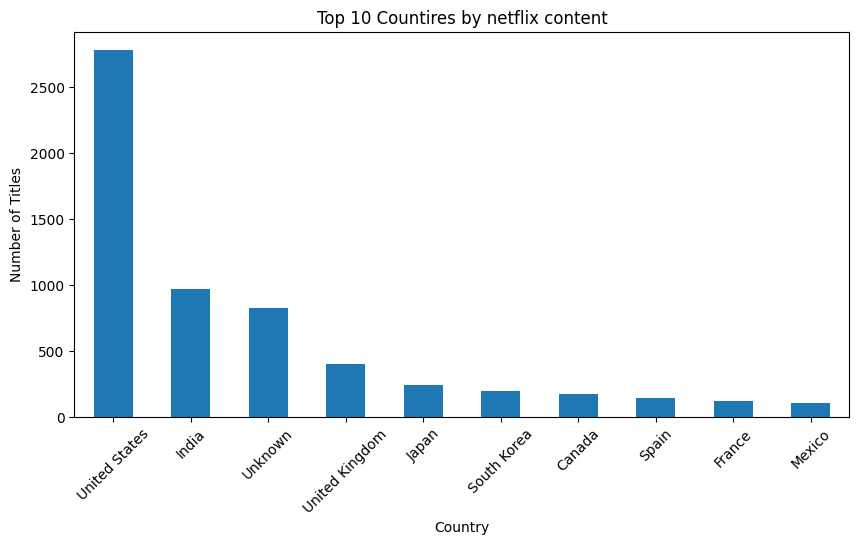

In [ ]:
top_countries=df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countires by netflix content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()



Chart 2: Line Chart

Netflix Content Releases by Year

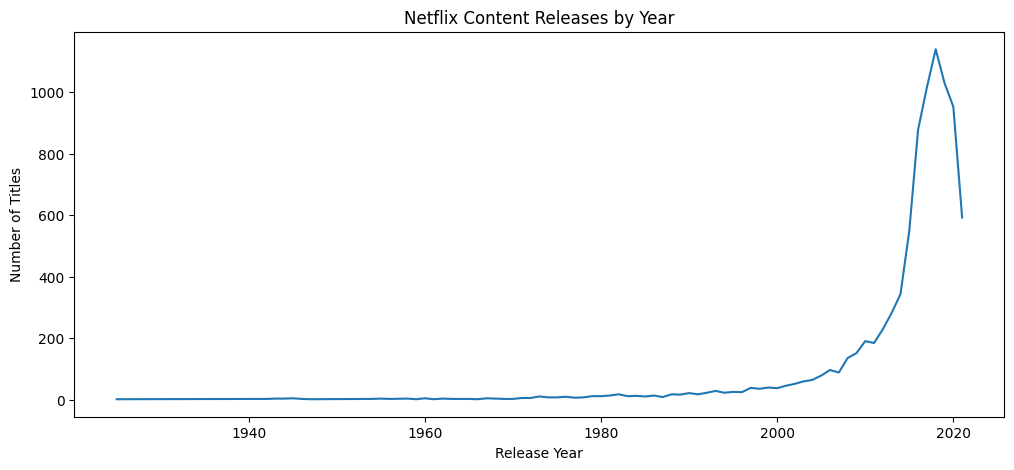

In [ ]:
release_trend=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,5))
plt.plot(release_trend.index,release_trend.values)
plt.title("Netflix Content Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

Chart 3: Histogram

Distribution of Movie Durations

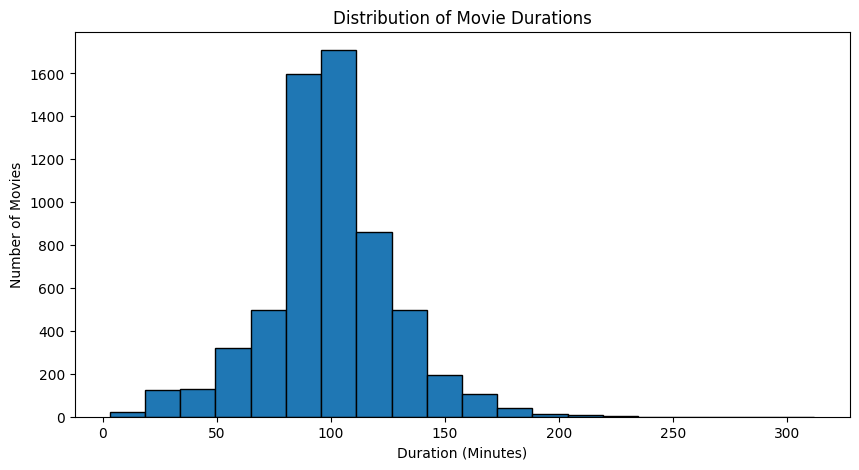

In [ ]:
movie_df=df[df['type']=='Movie'].copy()
movie_df['duration_num']=movie_df['duration'].str.extract(r'(\d+)').astype(float)
plt.figure(figsize=(10,5))
plt.hist(movie_df['duration_num'],bins=20,edgecolor="black")
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

Chart 4: Scatter plot

Release Year Vs Duration

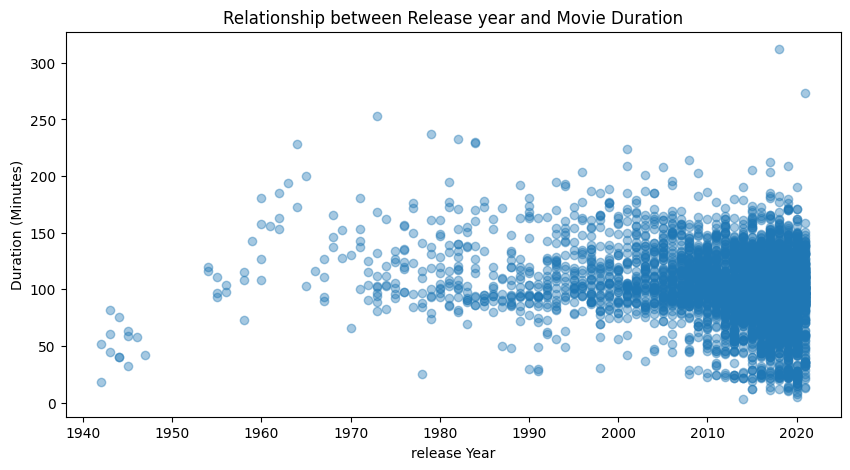

In [ ]:
movie_df=df[df['type']=='Movie'].copy()
movie_df['duration_num']=movie_df['duration'].str.extract(r'(\d+)').astype(float)
plt.figure(figsize=(10,5))
plt.scatter(movie_df['release_year'],movie_df['duration_num'],alpha=0.4)
plt.title("Relationship between Release year and Movie Duration")
plt.xlabel("release Year")
plt.ylabel("Duration (Minutes)")
plt.show()

Chart 5: Pie Chart

Movies vs Tv Shows

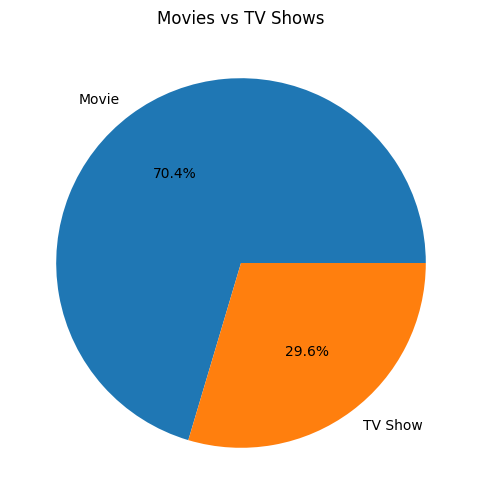

In [ ]:
content_type=df['type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(content_type,labels=content_type.index,autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

Chart 6: Heatmap
Correlation Heatmap

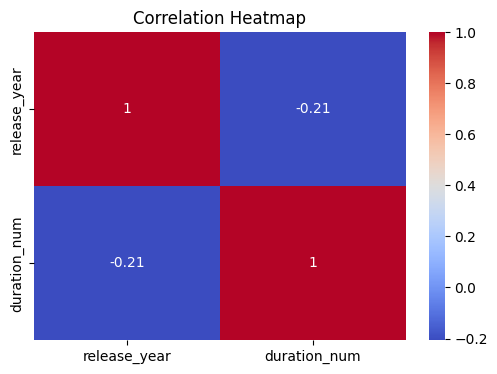

In [ ]:
numeric_df=movie_df[['release_year','duration_num']]
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Chart 7: Horizontal Bar Chart

Genre Distribution


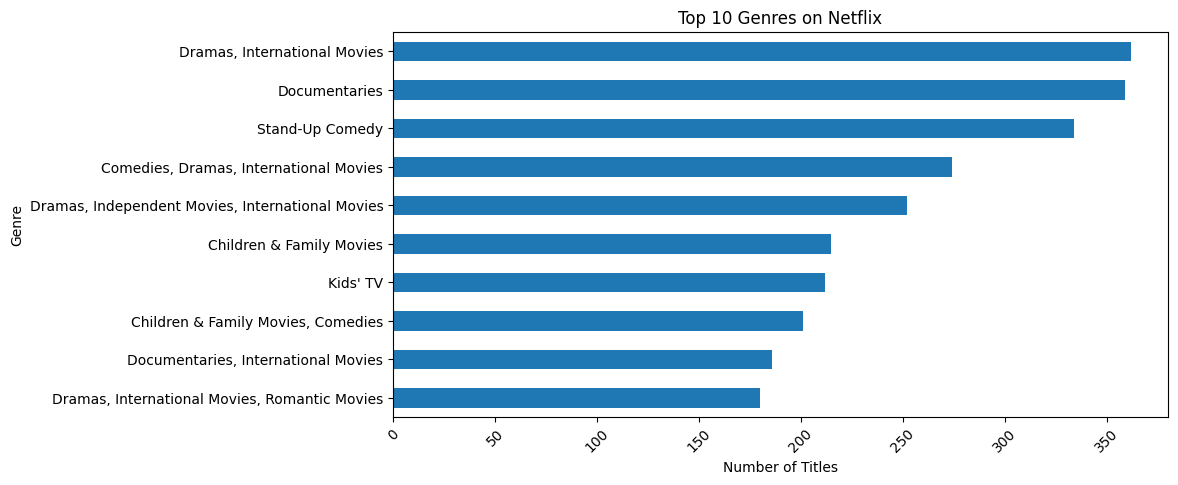

In [ ]:
top_genre=df['listed_in'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_genre.sort_values().plot(kind="barh")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.xticks(rotation=45)
plt.show()

#Step 5 - Insights Report
1.**Recent years show the highest content production on netflix.**
  Based on the Line Chart(Netflix content release by year) and question 1,the number of titles increased significantly after 2010,with the highest concentration of content appearing in recent years.This indicates Netflix's rapid expansion of its content library.

2.**A few countries contribute a large share of netflix content.**
  From the bar chart(Top 10 countries by netflix content) and question 2,countries such as the United States and India contribute the highest number of titles.This suggests that netflix relies heavily on a few major content-producing markets.

3.**Movies dominate the netflix catalog.**
  According to the piechart(Movies vs Tv shows),movies represent a larger share of the platform's content compared to TV shows.This indicated that netflix's catalog is primarily movie-oriented.

4.**Most netflix movies have a duration between 80 and 120 minutes.**
  The Histogram (Distribution of movie durations) shows that the majority of movies fall within the standard features-film duration range.extremely short and very long movies are relatively uncommon.

5.**Release year has little influence on movie duration.**
  The scatter plot(relationship between movie's release year and its Duration).Movies released in different years tend to have similar duration ranges,indicating that movie length  has remained relatively consistent over time.However a few outliers with unusually long durations are present in the dataset.


